In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from keras import Sequential

Actual Class: cats
Image: cat.4914.jpg


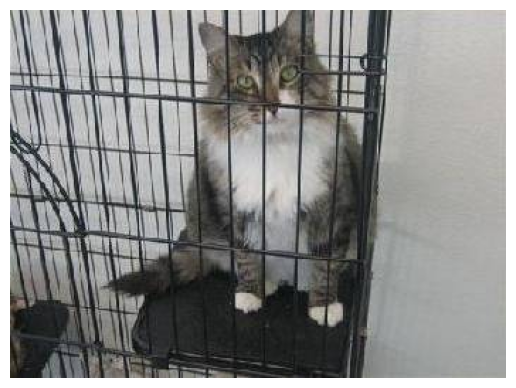

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Raw Prediction: 0.024671301
Actual: cats
Predicted: cats


In [ ]:
from pathlib import Path

base_path = Path(r"E:\DL_by_CompusX\PROJECTS\cat vs dog classification\dataset")

train_ds = keras.utils.image_dataset_from_directory(
    base_path / "training",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    base_path / "test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

In [3]:
# DATA PREPROCESSING (NORMALIZATION)

# Normalize pixel values from [0, 255] to [0, 1]
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [4]:
# create CNN  model

model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output Layer for Binary Classification
model.add(Dense(1, activation='sigmoid'))


e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# FLOW
# Image → Feature Extraction → Size Reduction → Feature Extraction → Size Reduction → Flatten → Classification → Cat/Dog

# Conv → Pool → Conv → Pool → Conv → Pool → Flatten → Dense → Dense → Output

In [25]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,937 (124.75 KB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compiling

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [6]:
# training

History = model.fit(train_ds , epochs=10 , validation_data=validation_ds)

Epoch 1/10


e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.5512 - loss: 3.2180 - val_accuracy: 0.5536 - val_loss: 1.0832
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.5569 - loss: 0.7969 - val_accuracy: 0.5922 - val_loss: 0.7381
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.6262 - loss: 0.6411 - val_accuracy: 0.6693 - val_loss: 0.5966
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.6612 - loss: 0.6035 - val_accuracy: 0.6480 - val_loss: 0.6239
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.6999 - loss: 0.5474 - val_accuracy: 0.7093 - val_loss: 0.5672
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.7312 - loss: 0.4982 - val_accuracy: 0.7148 - val_loss: 0.5626
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.7549 - loss: 0.4543 - val_accuracy: 0.7192 - val_loss: 0.7048
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 962s 4s/step - accuracy: 0.7785 - loss: 0.4149 - val_accuracy: 0.724

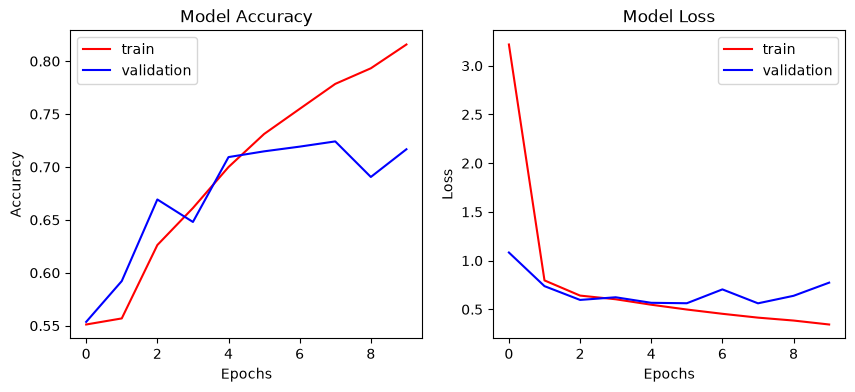

In [9]:
# EVALUATION (LOSS & ACCURACY PLOTS)
# Plot Accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(History.history['accuracy'], color='red', label='train')
plt.plot(History.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(History.history['loss'], color='red', label='train')
plt.plot(History.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Actual Class: cats
Image: cat.4060.jpg


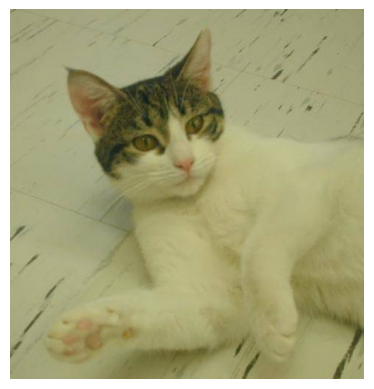

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Raw Prediction: 0.0006646691
Actual: cats
Predicted: cats


In [17]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Test dataset ka path
test_path = r"E:\DL_by_CompusX\PROJECTS\cat vs dog classification\dataset\test"

# Cat aur dog folders
classes = ["cats", "dogs"]

# Random class select karo
actual_class = random.choice(classes)

# Us class ke andar images ki list
class_path = os.path.join(test_path, actual_class)
images = os.listdir(class_path)

# Random image select karo
random_image = random.choice(images)

# Complete image path
image_path = os.path.join(class_path, random_image)

print("Actual Class:", actual_class)
print("Image:", random_image)

# Image read
test_img = cv2.imread(image_path)

# Display image
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

plt.imshow(test_img_rgb)
plt.axis("off")
plt.show()

# Resize
test_img_resized = cv2.resize(test_img, (256, 256))

# Add batch dimension
test_input = test_img_resized.reshape(1, 256, 256, 3)

# Normalize
test_input = test_input / 255.0

# Prediction
prediction = model.predict(test_input)

print("Raw Prediction:", prediction[0][0])

# Prediction
if prediction[0][0] < 0.5:
    predicted_class = "cats"
else:
    predicted_class = "dogs"

print("Actual:", actual_class)
print("Predicted:", predicted_class)